In [88]:
# ==============================================================================
# 시스템명: 전 수계 통합 오염원인 자동 스크리닝 및 자기 최적화 시스템 (Python Ver.)
# 연구과제: 안정동위원소 결합 오염평가 체계 고도화를 위한 국가 수질측정망 적용 연구
# ==============================================================================

# 필요 패키지 설치 및 임포트
!pip install torch pandas numpy scikit-learn matplotlib adjustText seaborn hdbscan

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
import hdbscan 
import torch
import torch.nn as nn
from adjustText import adjust_text
import warnings
import datetime
import random
import math

In [90]:
# 환경 설정 및 재현성 확보
warnings.filterwarnings('ignore')
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']
available = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = next((c for c in candidates if c in available), 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

In [91]:
SEED = 3606
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)            # GPU 사용 시
torch.backends.cudnn.deterministic = True   # CUDA 비결정성 차단
torch.backends.cudnn.benchmark = False

In [92]:
# ------------------------------------------------------------------------------
# 1. 데이터 전처리 (Data Pre-processing)
# 방법론: KNN Imputation & Z-score Normalization
# 설명: 결측치(Missing Value)를 단순 평균(Mean)이나 중앙값(Median)으로 대체할 경우, 
#       수질 인자 간의 다차원적 상관관계가 훼손될 수 있습니다. 이를 방지하기 위해 
#       다차원 공간에서 가장 유사한 K개의 샘플 특성을 참조하는 KNN 알고리즘을 사용합니다.
# 참고문헌: 
# - Troyanskaya, O., et al. (2001). "Missing value estimation methods for DNA microarrays." Bioinformatics, 17(6), 520-525. (다차원 데이터의 결측치 보간에 대한 KNN 우수성 검증)
# ------------------------------------------------------------------------------
df = pd.read_csv('C:/Users/User/Desktop/특이측정값(3~4월).csv', encoding='euc-kr') 
features_df = df.drop(columns=['spot'])

# [방법론] KNN Imputation (n_neighbors=5)
# 주변 5개 관측점의 수질 패턴 유클리디안 거리를 계산하여 결측치를 가중 평균으로 추정합니다.
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(features_df)
imputed_df = pd.DataFrame(imputed_data, columns=features_df.columns) 

# [방법론] StandardScaler
# EC(전기전도도)와 같이 스케일이 매우 큰 변수가 거리 기반 알고리즘이나 
# 신경망 학습을 지배(Dominate)하는 것을 막기 위해 모든 변수를 평균 0, 표준편차 1로 정규화합니다.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

In [93]:
# ------------------------------------------------------------------------------
# 2. 비선형 특징 추출 (Deep Learning Feature Extraction)
# 방법론: Undercomplete Autoencoder (AE)
# 설명: 수질 변수와 동위원소 데이터는 선형적이지 않은 복잡한 상호작용(예: 화학적 침전, 미생물 분해)을 
#       가집니다. 전통적인 선형 차원축소 기법인 PCA(주성분 분석)의 한계를 극복하기 위해, 
#       인공신경망 기반의 오토인코더를 사용하여 핵심적인 비선형 잠재 특징(Latent Features)을 추출합니다.
# 참고문헌:
# - Hinton, G. E., & Salakhutdinov, R. R. (2006). "Reducing the dimensionality of data with neural networks." Science, 313(5786), 504-507. (Autoencoder를 활용한 비선형 차원축소의 기초)
# ------------------------------------------------------------------------------
class UniversalAE(nn.Module):
    def __init__(self, input_dim):
        super(UniversalAE, self).__init__()
        
        # 1. 은닉층 단순화 (Deep -> Shallow 구조 변경)
        # 소표본 데이터(N=10 내외)에서는 파라미터 수가 너무 많으면 데이터를 통째로 외워버립니다.
        # 기존 [input -> 16 -> 8 -> 3] 구조를 [input -> 6 -> 3] 구조로 대폭 슬림화하여 모델의 표현 용량을 제한합니다.
        
        # 2. 드롭아웃(Dropout) 도입
        # 특정 수질 인자나 동위원소 값 하나에 모델이 과도하게 의존(Co-adaptation)하는 것을 방지합니다.
        # 학습 시 무작위로 20%의 노드를 끔으로써 변수 간의 균형 있는 관계를 학습하게 합니다.
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 6),       # 중간 레이어 노드를 16개에서 6개로 축소
            nn.ReLU(),
            nn.Dropout(p=0.2),             # 과적합 방지를 위한 드롭아웃 레이어 추가
            nn.Linear(6, 3)                # 최종 3차원 잠재 공간(Latent Space) 생성
        )
        
        # 디코더 역시 인코더와 대칭되도록 층을 단순화합니다.
        self.decoder = nn.Sequential(
            nn.Linear(3, 6),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(6, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        return latent, self.decoder(latent)

# 모델 인스턴스 생성 (scaled_data 변수가 사전에 정의되어 있어야 합니다)
model = UniversalAE(input_dim=scaled_data.shape[1])

# 3. L2 정규화(Weight Decay) 강도 대폭 상향
# 기존 1e-4는 소표본에서 가중치를 제어하기에 너무 약합니다. 
# weight_decay를 1e-2(100배 증가)로 상향하여 가중치들이 지나치게 커져 노이즈를 학습하는 것을 엄격히 차단합니다.
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-2)
criterion = nn.MSELoss()

# 입력 데이터를 파이토치 텐서로 변환
tensor_data = torch.FloatTensor(scaled_data)

# 4. 에포크(Epoch) 수 최적화
# 적은 데이터량에 비해 1200회 반복은 과적합을 유도하는 주원인입니다.
# 강건한 구조 하에서 데이터가 충분히 수렴할 수 있는 400~500회 내외로 조절합니다.
epochs = 400

for epoch in range(epochs):
    model.train() # [중요] 학습 모드 설정: Dropout이 활성화되어 과적합을 방지합니다.
    
    latent, recon = model(tensor_data)
    loss = criterion(recon, tensor_data)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # (선택 사항) 학습 과정 확인을 위해 50회마다 Loss를 출력합니다.
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# 5. 평가 모드(Evaluation Mode) 전환 후 최종 차원축소 데이터 추출
# [필수] 평가 모드로 변경해야 Dropout이 꺼지고 모든 노드가 활성화되어 '일관되고 정확한' 잠재 공간 좌표를 얻을 수 있습니다.
model.eval() 

with torch.no_grad(): # 그라디언트 계산을 비활성화하여 메모리 절약 및 연산 오류 방지
    latent_final, _ = model(tensor_data)

# 신경망이 추출한 안정한 3차원 축소 데이터 (이후 군집화 알고리즘의 입력값으로 안전하게 전달됨)
latent_data = latent_final.numpy()

Epoch [50/400], Loss: 0.8484
Epoch [100/400], Loss: 0.6434
Epoch [150/400], Loss: 0.5436
Epoch [200/400], Loss: 0.4793
Epoch [250/400], Loss: 0.5503
Epoch [300/400], Loss: 0.4841
Epoch [350/400], Loss: 0.4110
Epoch [400/400], Loss: 0.4586


In [94]:
# ------------------------------------------------------------------------------
# 3. 알고리즘 경합형 최적 모델 및 군집 수(K) 결정
# 방법론: Multi-Algorithm Ensemble & Silhouette Analysis
# 설명: 수질 데이터의 분포는 구형(K-Means 적합)일 수도, 밀도 기반 비정형(HDBSCAN 적합)일 수도 있습니다.
#       여러 알고리즘을 경쟁시켜 Silhouette Score (응집도와 분리도 평가 지표)가 가장 높은 
#       최적의 클러스터링 구조를 자동 채택합니다.
# 참고문헌:
# - Rousseeuw, P. J. (1987). "Silhouettes: a graphical aid to the interpretation and validation of cluster analysis." Journal of Computational and Applied Mathematics, 20, 53-65.
# - McInnes, L., et al. (2017). "hdbscan: Hierarchical density based clustering." The Journal of Open Source Software.
# ------------------------------------------------------------------------------
print("[*] 1차 스크리닝을 위한 최적 오염원 분류 모델 탐색을 시작합니다...")
competition_results = []
n = len(df)
if n > 8:
    search_range = range(4, 9)
elif n >= 5:
    search_range = range(4, min(8, n))  # 최소 4 유지, 가능한 범위만
else:
    raise ValueError(f"표본 수 부족 (n={n}). 최소 5 이상 권장.")

# (A) HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
# 노이즈를 식별하고 비선형적인 밀도 기반 군집을 형성하는 데 매우 탁월함.
hdb = hdbscan.HDBSCAN(min_cluster_size=2).fit(latent_data)
if len(set(hdb.labels_)) > 1:
    mask = hdb.labels_ != -1 
    if np.sum(mask) > 1:
        score = silhouette_score(latent_data[mask], hdb.labels_[mask])
        k_hdb = len(set(hdb.labels_[mask]))
        if k_hdb in search_range:
            competition_results.append({'model': 'HDBSCAN', 'k': k_hdb, 'score': score, 'labels': hdb.labels_})

# (B) 다양한 군집 알고리즘 경쟁 (Spectral, Birch, GMM)
for k in search_range:
    # Spectral Clustering: 데이터의 그래프 표현을 생성하여 군집 간의 연결성(Connectivity)을 기반으로 분류
    spec = SpectralClustering(n_clusters=k, affinity='rbf', random_state=SEED).fit(latent_data)
    competition_results.append({'model': 'Spectral', 'k': k, 'score': silhouette_score(latent_data, spec.labels_), 'labels': spec.labels_})
    
    # Birch: 트리 구조를 활용하여 대용량 데이터를 빠르고 계층적으로 군집화
    birch = Birch(n_clusters=k).fit(latent_data)
    competition_results.append({'model': 'Birch', 'k': k, 'score': silhouette_score(latent_data, birch.labels_), 'labels': birch.labels_})

    # Gaussian Mixture Model (GMM): 데이터를 여러 개의 정규분포 혼합으로 모델링 (소프트 클러스터링 기반)
    gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=SEED).fit(latent_data)
    labels_gmm = gmm.predict(latent_data)
    if len(set(labels_gmm)) > 1:
        competition_results.append({'model': 'GMM', 'k': k, 'score': silhouette_score(latent_data, labels_gmm), 'labels': labels_gmm})

# 최적화 결과 선정
if not competition_results:
    print("[!] 설정한 군집 범위(4~8) 내에서 적절한 모델을 찾지 못했습니다. 탐색 범위를 넓히거나 데이터를 재검토하십시오.")
else:
    best_run = max(competition_results, key=lambda x: x['score'])
    df['Cluster'] = best_run['labels']
    best_k = best_run['k']

print("=========================================================")
print(f"[*] 통계적 검증을 통한 최종 선정 최적 알고리즘: {best_run['model']}")
print(f"[*] 데이터 내재 구조를 반영한 최적 군집 수(K): {best_k}개")
print(f"[*] 모델 분류 성능(Silhouette Score): {best_run['score']:.4f}")
print("=========================================================\n")

# HDBSCAN에서 분류하지 못한 노이즈(-1)를 가장 가까운 군집(1-NN)에 재할당하여 실무 적용성 향상
if best_run['model'] == 'HDBSCAN' and -1 in df['Cluster'].values:
    print("[!] HDBSCAN 모델의 노이즈(-1) 지점을 인접 특성 군집으로 재할당(KNN 보정) 합니다.")
    knn = KNeighborsClassifier(n_neighbors=1) 
    valid_mask = df['Cluster'] != -1
    knn.fit(latent_data[valid_mask], df['Cluster'][valid_mask])
    df.loc[~valid_mask, 'Cluster'] = knn.predict(latent_data[~valid_mask])

[*] 1차 스크리닝을 위한 최적 오염원 분류 모델 탐색을 시작합니다...
[*] 통계적 검증을 통한 최종 선정 최적 알고리즘: GMM
[*] 데이터 내재 구조를 반영한 최적 군집 수(K): 4개
[*] 모델 분류 성능(Silhouette Score): 0.4675



In [95]:
# ------------------------------------------------------------------------------
# 4. 범용적 10단계 오염원 정밀 판별 엔진 (Universal Multi-Proxy Rule)
# 방법론: Dual Isotope (d15N, d18O) & Hydrochemical Multi-Tracer (Cl, NO3, NH3, TOC 등)
# 설명: 동위원소만으로는 축산분뇨와 생활하수 등의 구분이 모호할 수 있으므로, 
#       보존성 이온인 염소(Cl-)와 유기물 지표(TOC) 등을 교차 검증(Multi-proxy)하여 오염 기원을 판별합니다.
# 참고문헌:
# - Xue, D., et al. (2009). "Present state and future prospects of isotope methods for monitoring nitrogen pollution." Water Research, 43(20), 5159-5170. (질소, 산소 동위원소 범위 기반 오염원 분류)
# - Böttcher, J., et al. (1990). "Using isotope fractionation of nitrate-nitrogen and nitrate-oxygen for evaluation of microbial denitrification in a sandy aquifer." Journal of Hydrology. (탈질작용에 따른 동위원소 분배 비율 증명)
# - Panno, S. V., et al. (2006). "Characterization and identification of Na-Cl sources in ground water." Ground Water, 44(2), 176-187. (염소 이온을 이용한 하수 및 분뇨 유래 오염 식별)
# ------------------------------------------------------------------------------
def assign_source_universal(row):
    n15, o18, tp, nh3, no3, toc, ec, chl, tn, cl = \
        row['d15N'], row['d18O'], row['TP'], row['NH3N'], row['NO3N'], row['TOC'], row['EC'], row['Chla'], row['TN'], row['Cl']

    # 관련 항목이 모두 결측 시 판정 불가 명시
    if any(math.isnan(v) for v in [n15, o18, tp, nh3, toc, ec, chl, tn, cl]):
        return "결측-판정보류"

    # [판별 로직 1] 대기 유입: d18O가 15‰ 이상일 경우, 질산염이 대기 강하물이나 강우에 의해 직접 유입된 것으로 판단.
    if o18 > 15.0: return "대기유입/초기강우"
    
    # [판별 로직 2] 탈질작용(Denitrification): 혐기성 조건에서 미생물이 질산염을 분해할 때, 
    # 무거운 동위원소(15N, 18O)가 잔류하여 농축됨. 이 때 농축 비율이 대략 1:1 ~ 2:1 범위로 발생함. (Böttcher et al., 1990)
    if n15 > 6.0 and o18 > 3.0 and (1.0 <= n15/o18 <= 2.5): return "탈질작용(기원변형)"
    
    # [판별 로직 3] 축산분뇨: 매우 높은 d15N(>12‰) 시그널과 함께 요소 분해에 따른 고농도 암모니아(NH3), 
    # 동물의 사료 섭취로 인한 고염소(Cl>60)를 동반함.
    if n15 > 12.0 and (cl > 60 or nh3 > 0.3): return "축산분뇨 직접유출"
    
    # [판별 로직 4] 생활하수: d15N이 7~12‰ 범위이며, 인위적 염소(세제, 식염 등 Cl>40)가 확인되는 경우.
    if 7.0 < n15 <= 12.0 and (cl > 40 or tp <= 0.3): return "생활하수/처리수 영향"
    
    # [판별 로직 5] 산업/인위적 점오염: EC(전기전도도)가 비정상적으로 높고(>500) 고농도 Cl 및 유기물(TOC)을 동반.
    if n15 > 7.0 and (ec > 500 or cl > 100) and toc > 3.0: return "산업/인위적 점오염"
    
    # [판별 로직 6] 화학비료: 요소비료 등은 대기 중 질소를 고정하여 만들므로 d15N이 대기(0‰)와 유사하게 매우 낮음(<4‰).
    if n15 < 4.0 and no3 > 2.0 and cl < 30: return "화학비료 기반 농경지"
    
    # [판별 로직 7] 토양유기물 및 퇴비: 토양 미생물 과정에 의해 d15N이 4~9‰ 수준을 보이며 TOC가 동반됨.
    # Cl 이온이 높을 경우 가축분뇨가 섞인 유기질 퇴비로, 낮을 경우 순수 토양 유기물로 구분.
    if 4.0 <= n15 <= 9.0 and toc > 4.0:
        return "유기질비료(퇴비) 영향" if cl > 35 else "토양유기물/야생동물배설물"
    
    # [판별 로직 8] 조류 증식(Autochthonous): 수체 내 식물플랑크톤 광합성으로 인해 Chl-a와 TOC가 동시에 매우 높음.
    if chl > 40.0 and toc > 4.5: return "조류증식(현장발생)"
    
    # [판별 로직 9] 내생부하(Internal Loading): 정체 수역에서 퇴적물로부터 인(TP)과 유기물(TOC)이 용출되는 현상.
    if toc > 6.5 and tp > 0.1: return "내생부하(정체수역 유기물 축적)"
    
    # [판별 로직 10] 복합 및 배경: 명확한 특성 지표를 초과하지 않으나, 일부 영양염류가 높은 경우 우세 지표로 추정.
    if tp > 0.1 or cl > 50: return "복합오염(하수/분뇨 기여 우세)"
    elif no3 > 2.0: return "복합오염(농경지 비점 우세)"
    else: return "자연배경/특이징후 없음"

# [보완] 군집 모드(Mode) 할당
# 동일한 군집(Cluster) 내에서는 수질 거동이 유사하므로, 해당 군집 내 가장 빈도수가 높은 
# 판별 결과를 그 군집의 '대표 오염 기원'으로 설정하여 이상치(Outlier)로 인한 오판을 방지합니다.
imputed_df['Individual_Source'] = imputed_df.apply(assign_source_universal, axis=1)
imputed_df['Cluster'] = df['Cluster']
cluster_mode = imputed_df.groupby('Cluster')['Individual_Source'].agg(lambda x: x.mode()[0]).to_dict()
df['Source_Name'] = df['Cluster'].map(cluster_mode)

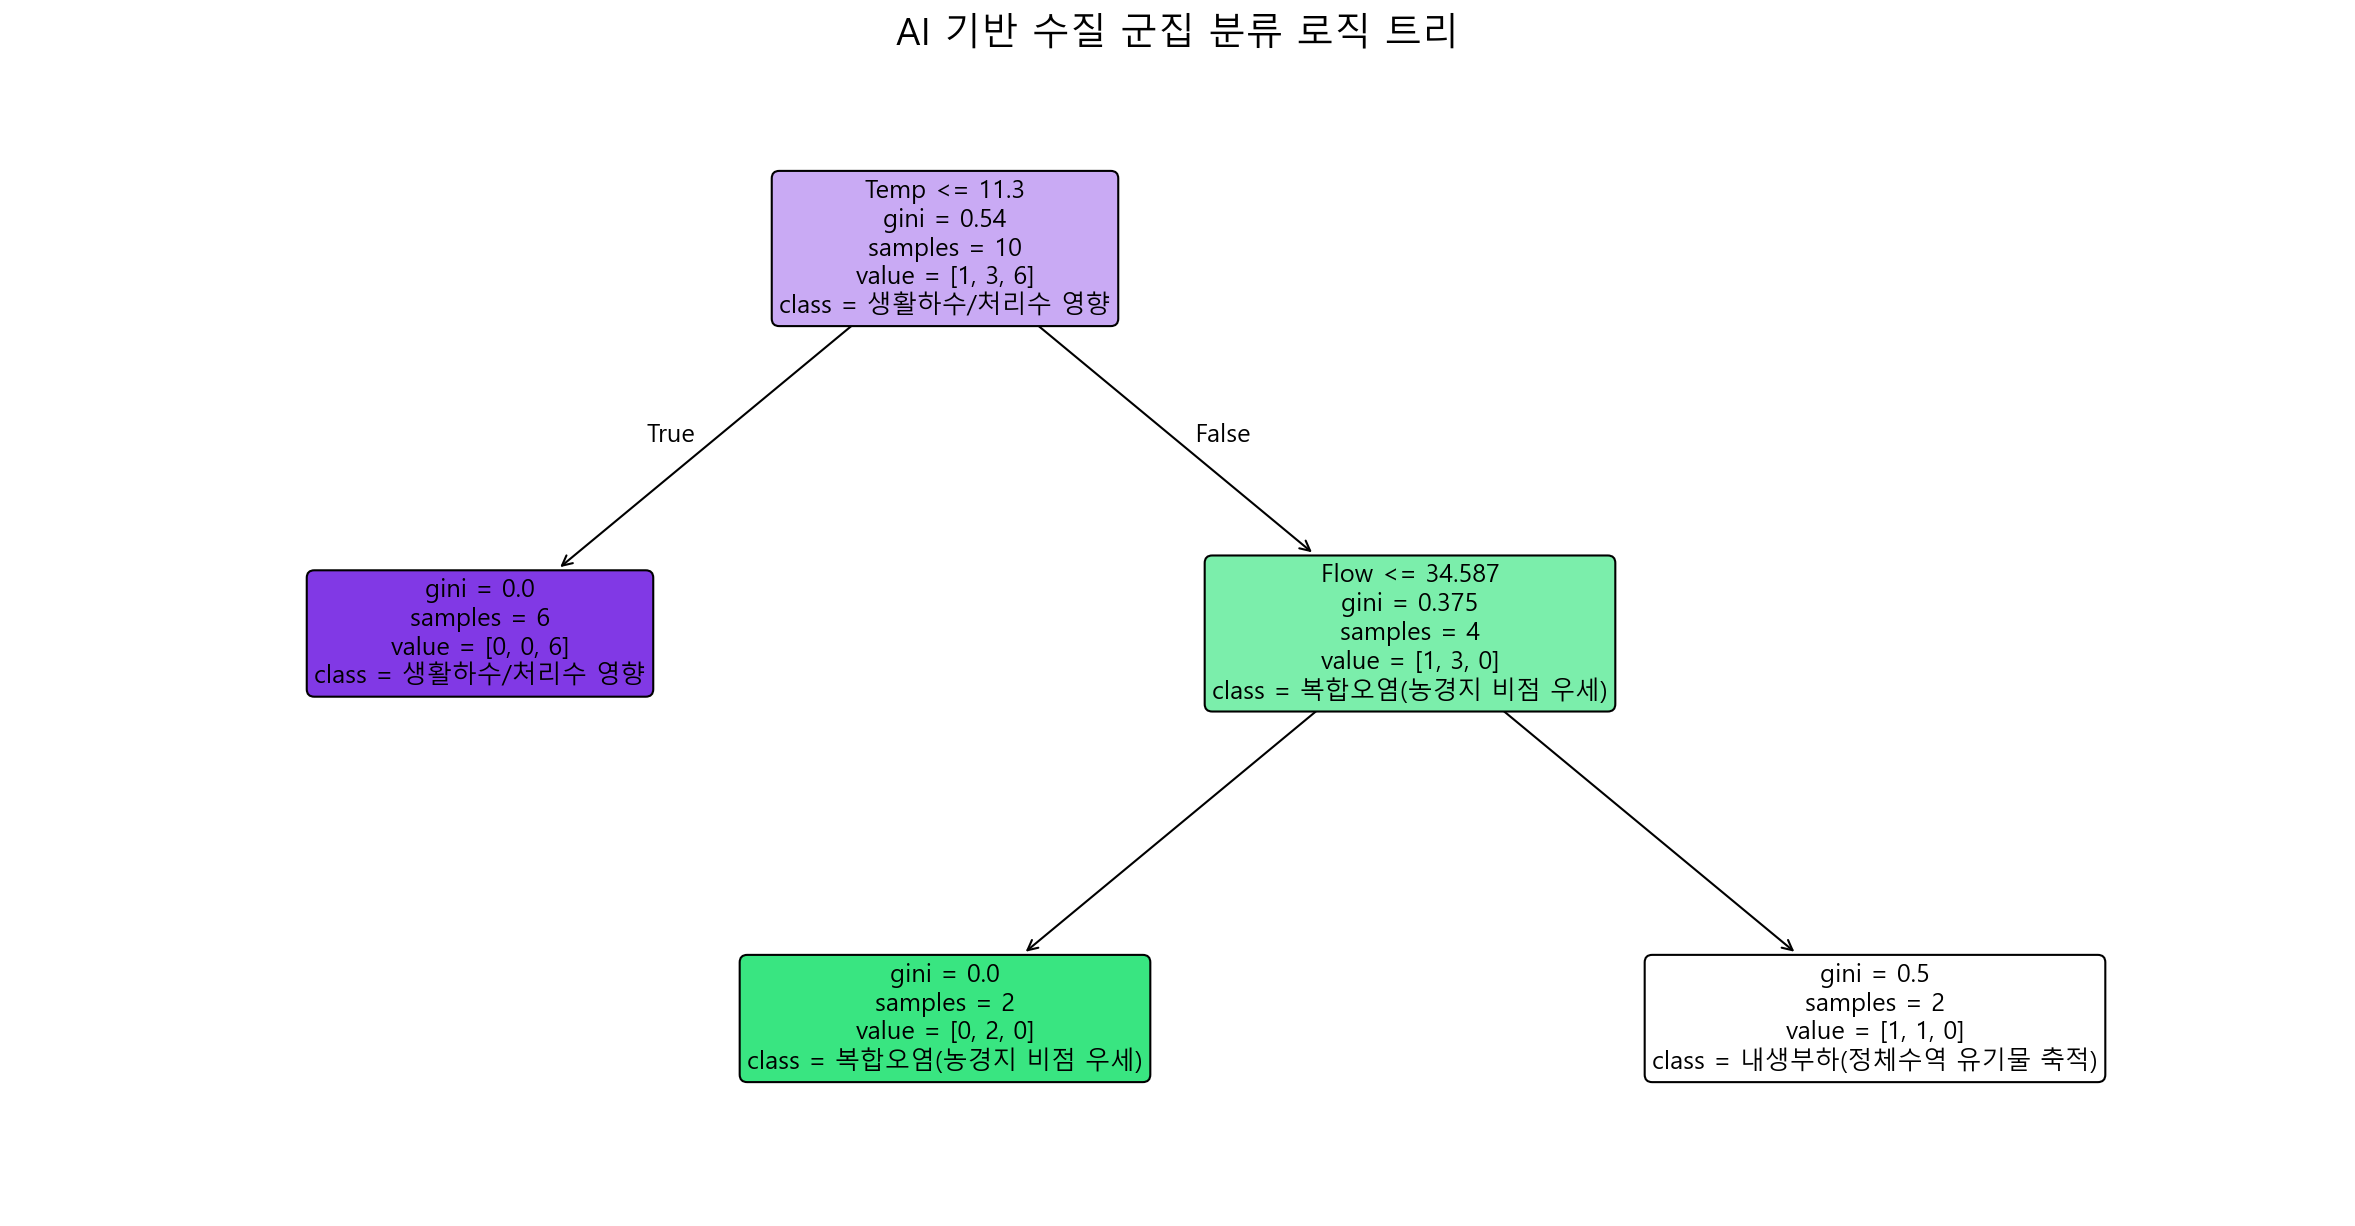

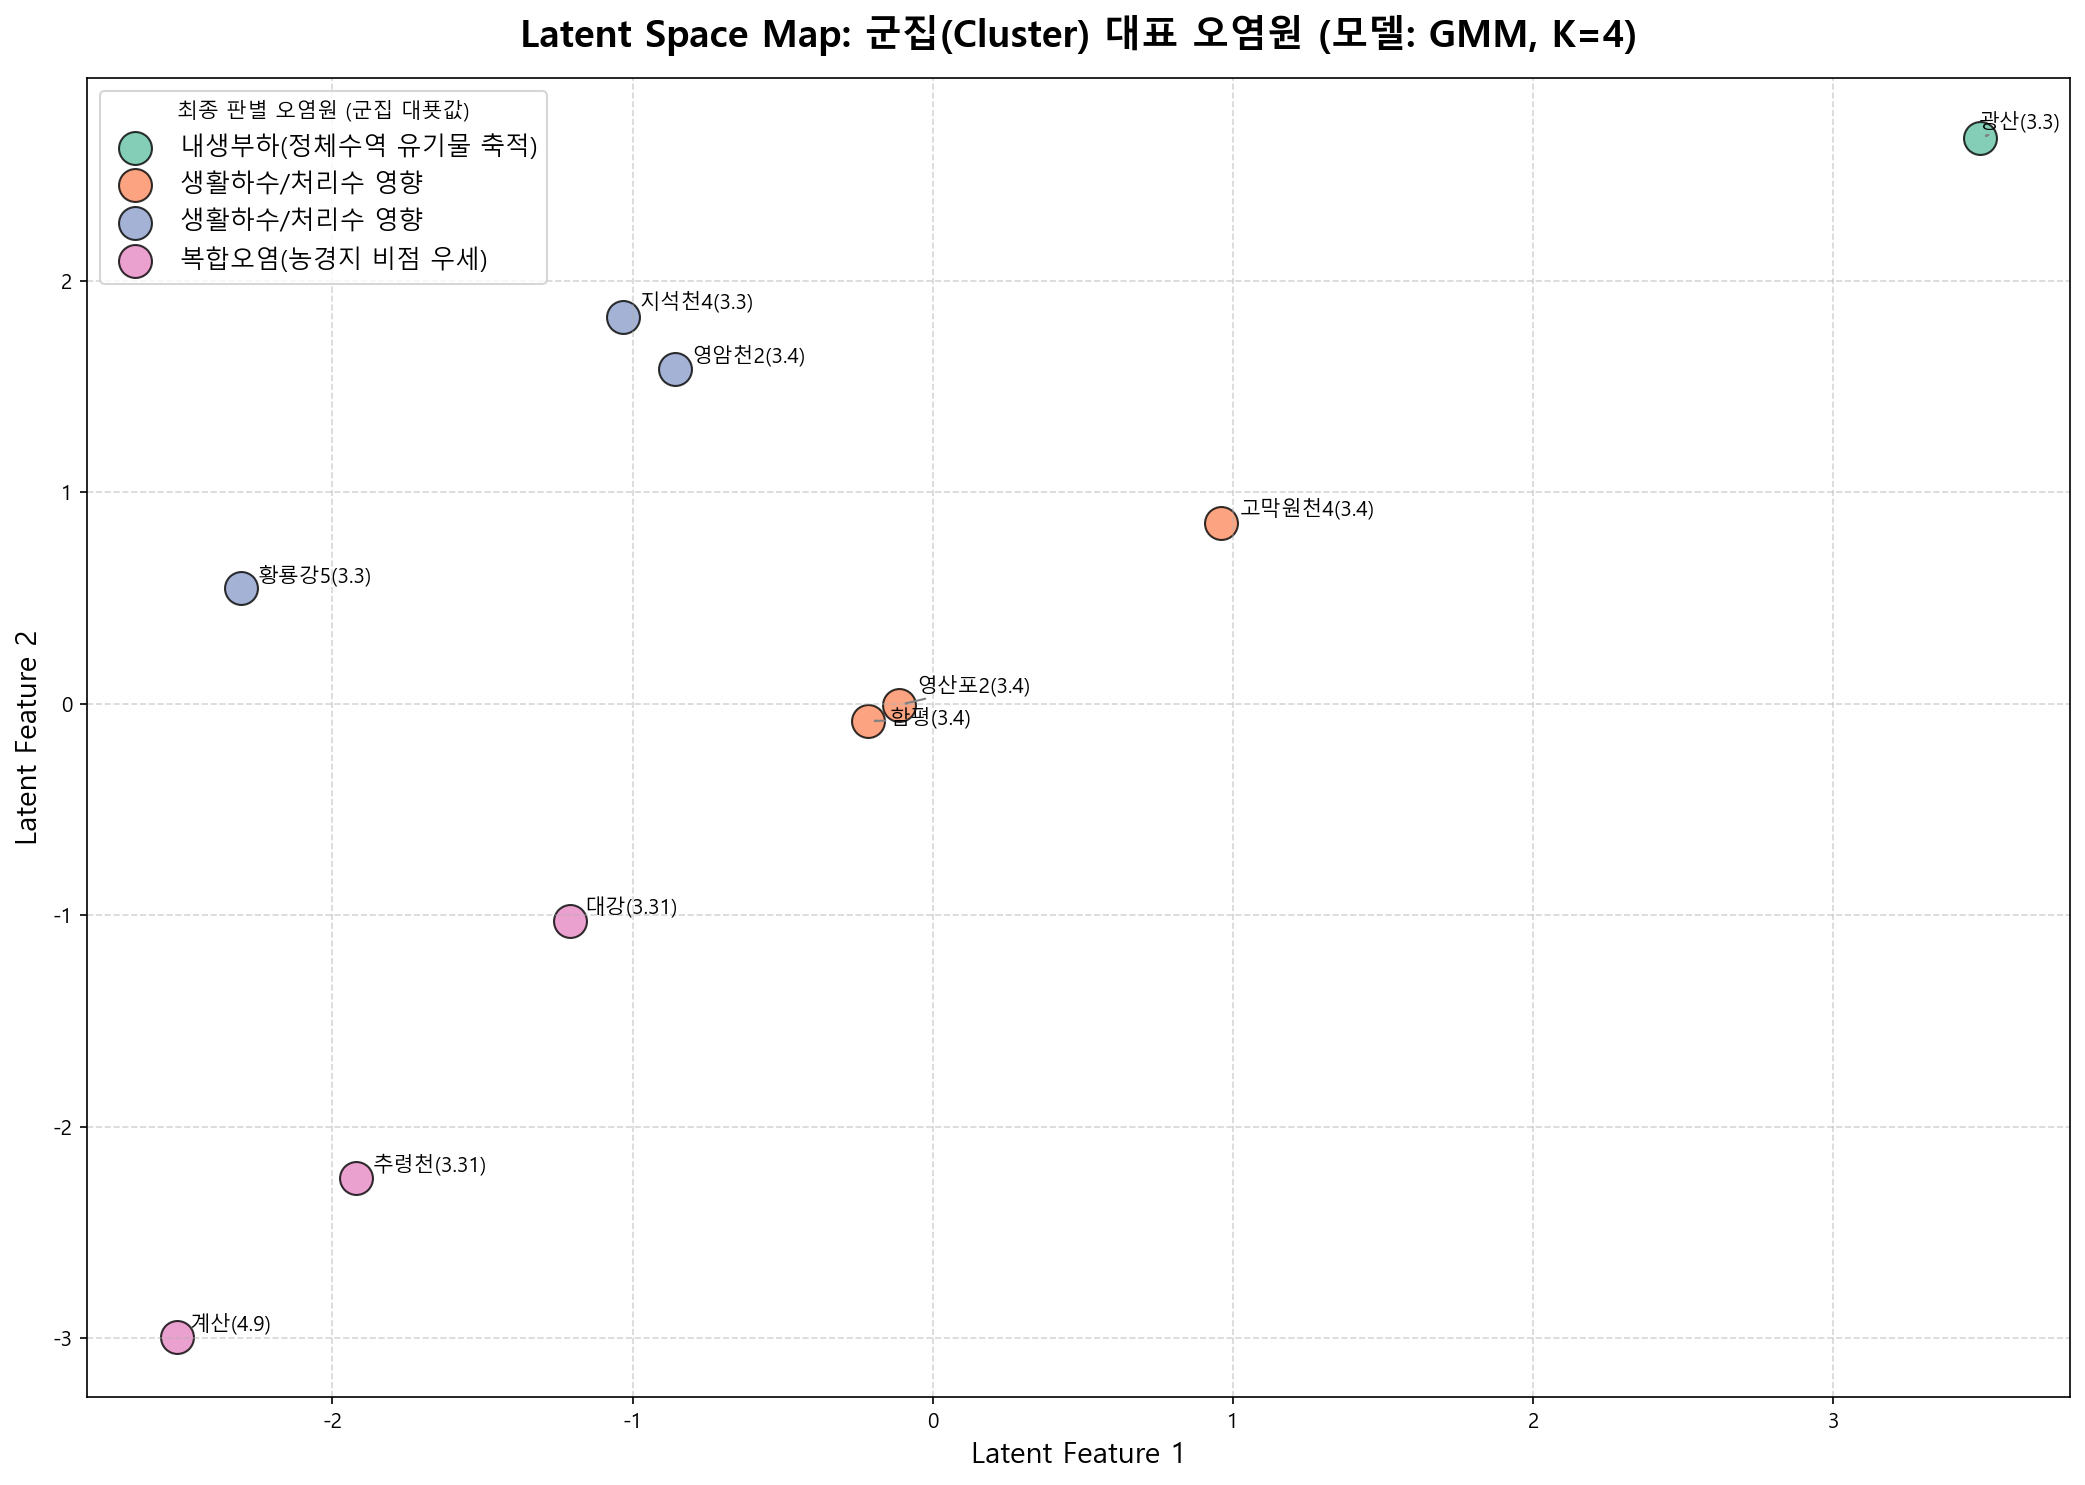

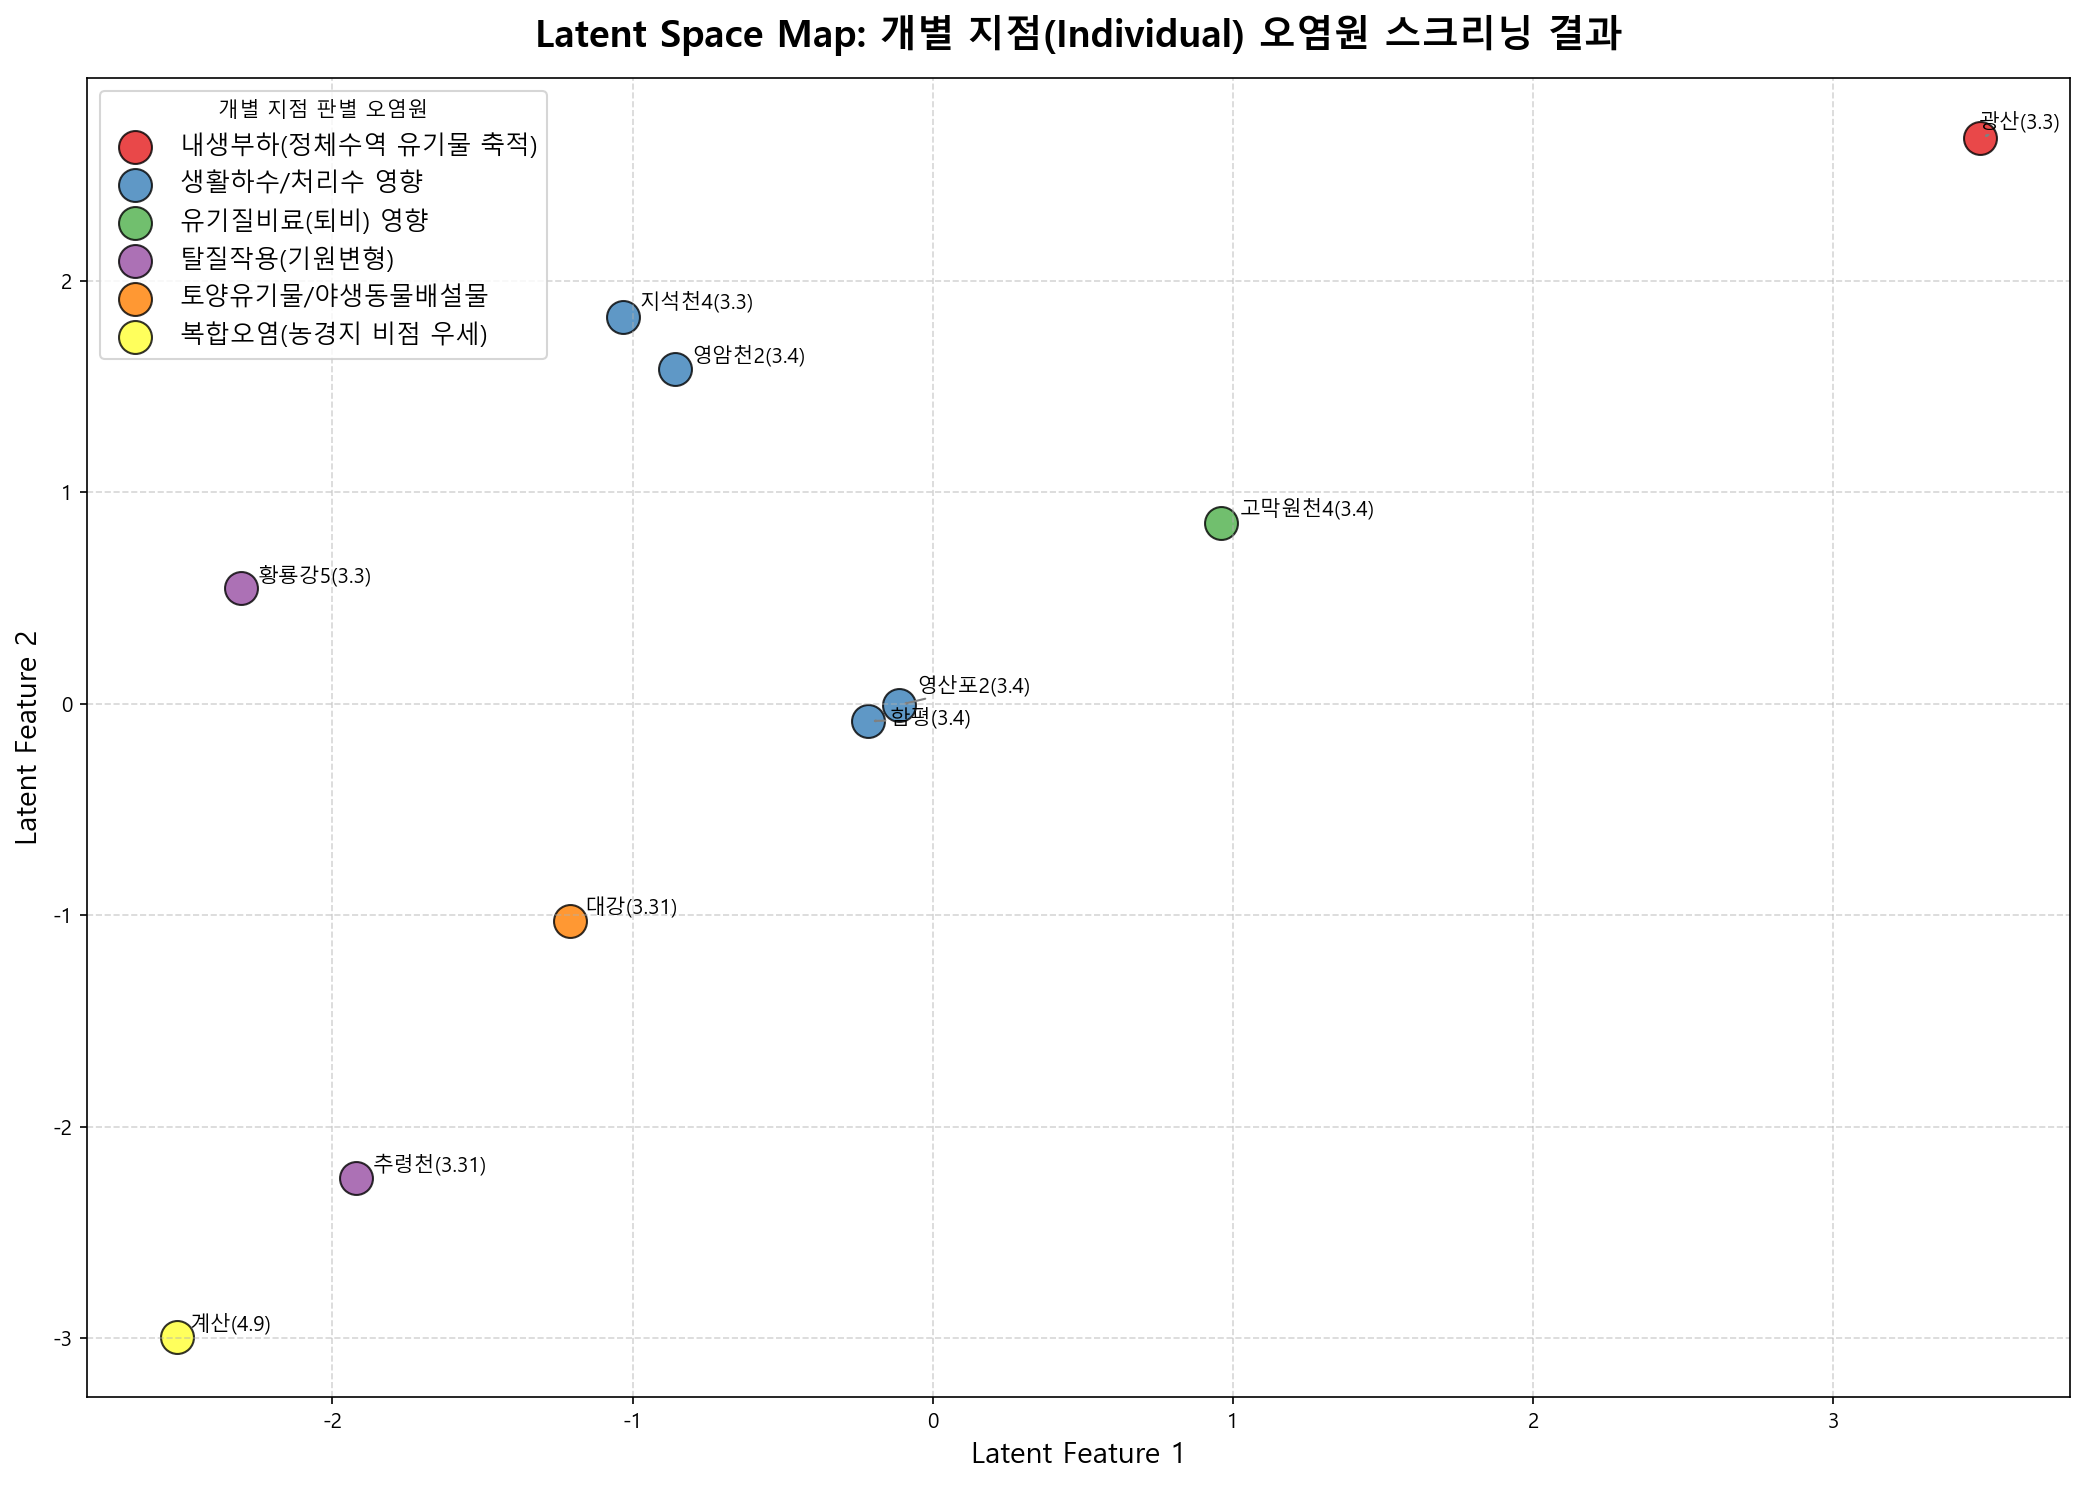

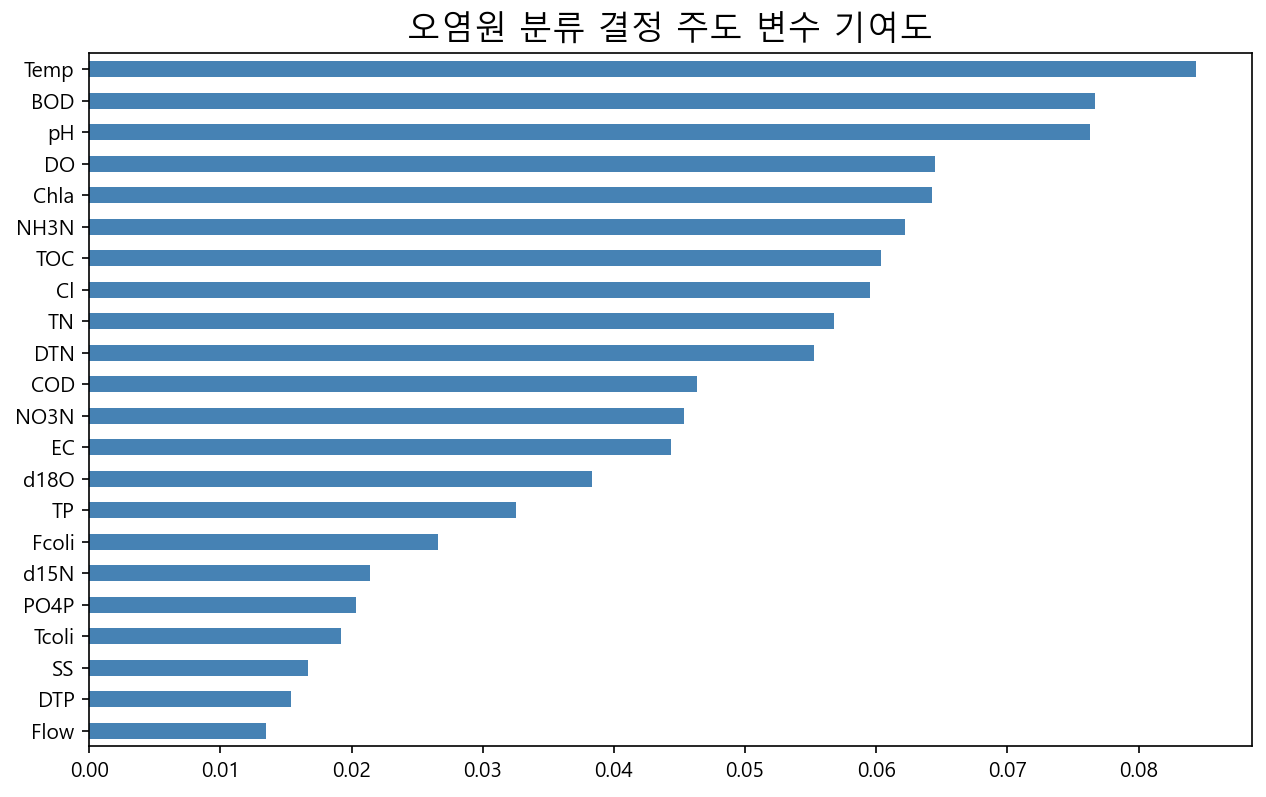

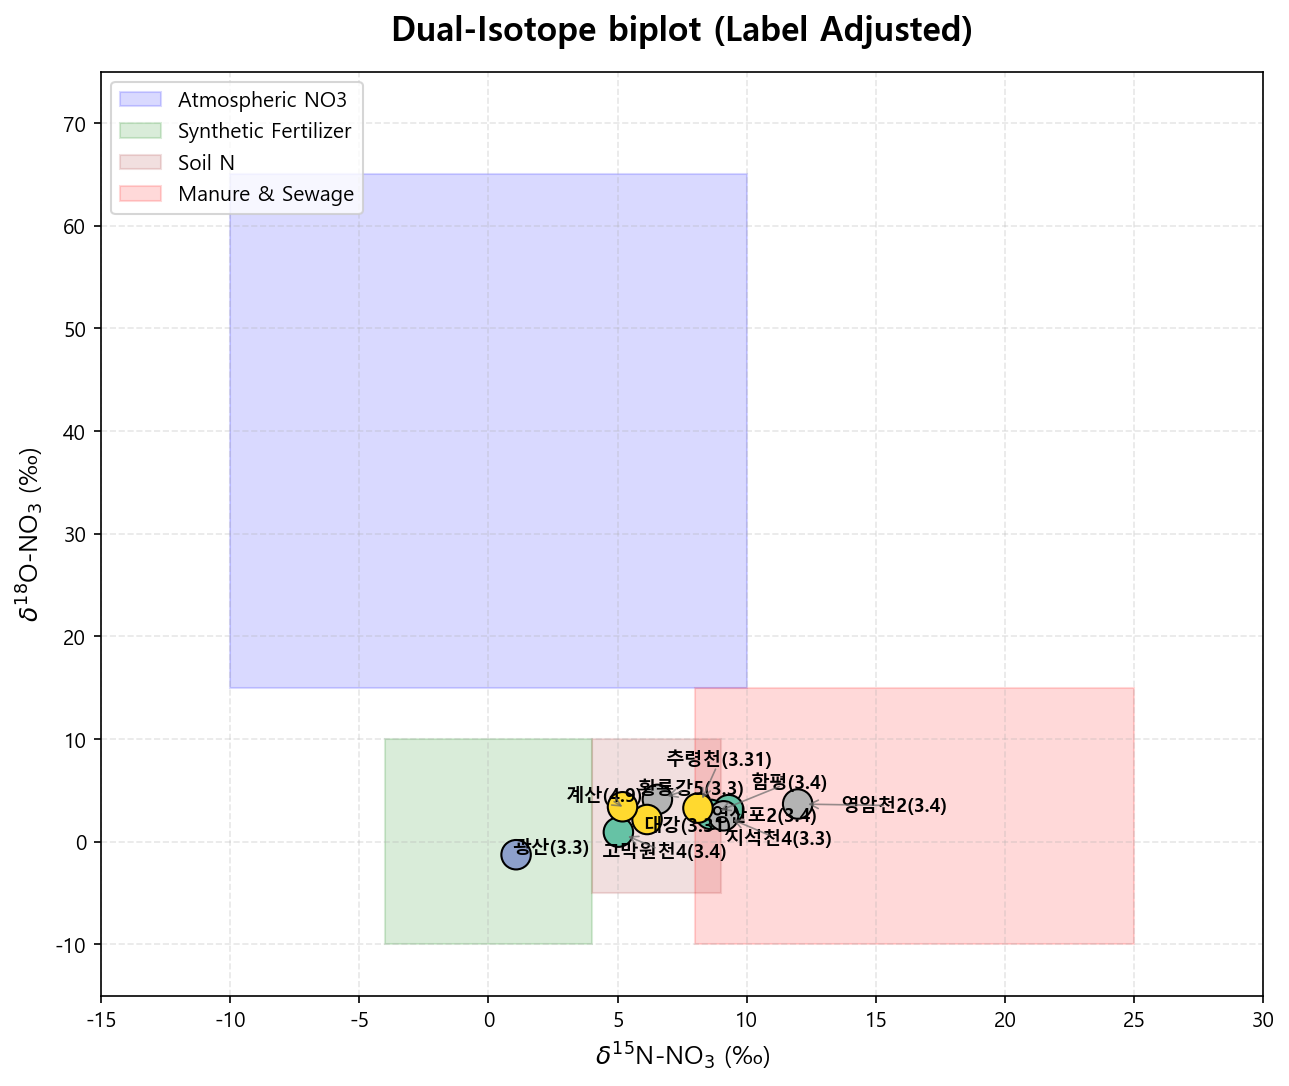

In [96]:
# ------------------------------------------------------------------------------
# 5. 시각화 및 PNG 저장
# 방법론: XAI (Explainable AI) - Decision Tree & Feature Importance (Random Forest)
# 설명: 신경망과 앙상블 군집화는 과정이 투명하지 않은 '블랙박스(Black-box)' 모델입니다. 
#       분석 결과를 연구자와 실무자가 직관적으로 이해할 수 있도록, 의사결정 나무를 통해 
#       어떤 수질 항목의 임계값(Threshold)이 오염원 분류에 결정적이었는지 시각화합니다.
# 참고문헌:
# - Breiman, L. (2001). "Random Forests." Machine Learning, 45(1), 5-32. (변수 중요도 산출의 근거)
# - Lundberg, S. M., & Lee, S. I. (2017). "A unified approach to interpreting model predictions." Advances in neural information processing systems, 30. (XAI를 통한 모델 해석력 확보)
# ------------------------------------------------------------------------------
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")

# (1) Decision Tree: 군집별 오염원 결정 논리를 트리 구조로 시각화
dt_model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=2, random_state=SEED)
dt_model.fit(imputed_data, df['Source_Name']) 

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=features_df.columns, class_names=[str(c) for c in dt_model.classes_],
          filled=True, rounded=True, fontsize=12)
plt.title("AI 기반 수질 군집 분류 로직 트리", fontsize=18)
plt.savefig(f"Decision_Tree_{current_time}.png", dpi=300, bbox_inches='tight')
plt.show()

# (2) 잠재 공간 지문 지도 (Latent Space Map)
# Autoencoder로 축소한 2차원 또는 3차원 공간(여기서는 앞의 2개 차원 활용)에 투영하여, 
# 오염원 간의 공간적 거리와 분리도를 직관적으로 확인합니다.
# 원본 데이터프레임에서 개별 룰베이스 판별 결과를 가져옵니다.
df['Individual_Source'] = imputed_df['Individual_Source'] 

# --- [2-A] 최종 '군집(Cluster)' 기준 오염원 판별 결과 지도 ---
plt.figure(figsize=(14, 10))
unique_clusters = df['Cluster'].unique()
# 각 군집의 대표 오염원(최빈값) 매핑
mapping_cluster = {cluster: df[df['Cluster'] == cluster]['Source_Name'].iloc[0] for cluster in unique_clusters}
colors_cluster = sns.color_palette('Set2', len(mapping_cluster))

for i, cluster_id in enumerate(mapping_cluster.keys()):
    mask = df['Cluster'] == cluster_id
    plt.scatter(latent_data[mask, 0], latent_data[mask, 1], 
                label=mapping_cluster[cluster_id], s=250, color=colors_cluster[i], edgecolors='k', alpha=0.8)

texts_cluster = [plt.text(latent_data[i, 0], latent_data[i, 1], df['spot'].iloc[i], fontsize=10) for i in range(len(df))]
adjust_text(texts_cluster, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

plt.title(f"Latent Space Map: 군집(Cluster) 대표 오염원 (모델: {best_run['model']}, K={best_k})", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Latent Feature 1", fontsize=14)
plt.ylabel("Latent Feature 2", fontsize=14)
plt.legend(title="최종 판별 오염원 (군집 대푯값)", loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# [수정] 파일명이 중복되지 않도록 Map_Cluster 로 저장
plt.savefig(f"Latent_Space_Map_Cluster_{current_time}.png", dpi=300, bbox_inches='tight')
plt.show()

# --- [2-B] '개별 지점(Individual)' 기준 오염원 판별 결과 지도 ---
plt.figure(figsize=(14, 10))
# [수정] Cluster가 아닌 'Individual_Source'를 기준으로 고유값을 추출하고 색상을 부여합니다.
unique_individual_sources = df['Individual_Source'].dropna().unique()
# [보완] 군집 맵과 색상을 다르게(Set1) 하여 시각적 혼선을 방지합니다.
colors_ind = sns.color_palette('Set1', len(unique_individual_sources))

for i, source in enumerate(unique_individual_sources):
    mask = df['Individual_Source'] == source  # [핵심 수정] 개별 오염원 기준으로 마스킹
    plt.scatter(latent_data[mask, 0], latent_data[mask, 1], 
                label=source, s=250, color=colors_ind[i], edgecolors='k', alpha=0.8)

texts_ind = [plt.text(latent_data[i, 0], latent_data[i, 1], df['spot'].iloc[i], fontsize=10) for i in range(len(df))]
adjust_text(texts_ind, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

plt.title(f"Latent Space Map: 개별 지점(Individual) 오염원 스크리닝 결과", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Latent Feature 1", fontsize=14)
plt.ylabel("Latent Feature 2", fontsize=14)
plt.legend(title="개별 지점 판별 오염원", loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# [수정] 파일명이 중복되지 않도록 Map_Individual 로 저장
plt.savefig(f"Latent_Space_Map_Individual_{current_time}.png", dpi=300, bbox_inches='tight')
plt.show()

# (3) Feature Importance: Random Forest를 사용하여 각 변수(동위원소, 수질항목 등)가 
# 전체 군집을 분할하는데 미친 지니 불순도(Gini Impurity) 감소 기여도를 산출합니다.
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=SEED).fit(imputed_data, df['Cluster'])
importances = pd.Series(rf.feature_importances_, index=features_df.columns).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title("오염원 분류 결정 주도 변수 기여도", fontsize=16)
plt.savefig(f"Feature_Importance_{current_time}.png", dpi=300, bbox_inches='tight')
plt.show()

# (4) Dual-Isotope biplot (Kendall (1998))
fig, ax = plt.subplots(figsize=(10, 8))

# [1] Kendall 표준 영역 (배경 박스) 기입
ax.add_patch(plt.Rectangle((-10, 15), 20, 50, fill=True, alpha=0.15, color='blue', label='Atmospheric NO3'))
ax.add_patch(plt.Rectangle((-4, -10), 8, 20, fill=True, alpha=0.15, color='green', label='Synthetic Fertilizer'))
ax.add_patch(plt.Rectangle((4, -5), 5, 15, fill=True, alpha=0.15, color='brown', label='Soil N'))
ax.add_patch(plt.Rectangle((8, -10), 17, 25, fill=True, alpha=0.15, color='red', label='Manure & Sewage'))

# [2] 데이터 산점도 그리기 (zorder를 높여 박스 위로 올림)
scatter = ax.scatter(df['d15N'], df['d18O'], c=df['Cluster'], cmap='Set2', s=200, edgecolors='k', zorder=3)

# [3] [수정] adjust_text 적용을 위한 텍스트 객체 리스트 생성
texts = []
for i, txt in enumerate(df['spot']):
    # 기존 ax.annotate 대신 ax.text를 사용하여 배치 후 리스트에 저장
    t = ax.text(df['d15N'].iloc[i], df['d18O'].iloc[i], txt, fontsize=9, fontweight='semibold')
    texts.append(t)

# [4] [핵심 추가] 글자 위치 자동 최적화 및 지시선 생성
# arrowprops를 통해 밀려난 글자와 원래 좌표 점 사이에 깔끔한 회색 화살표(->)를 연결합니다.
# shrinkA=5: 화살표가 지점명 글자에서 5포인트 떨어져서 시작하도록 설정
# shrinkB=5: 화살표가 원래 데이터 점(Scatter point)에서 5포인트 떨어져서 끝나도록 설정
adjust_text(texts, 
            arrowprops=dict(arrowstyle='->', 
                            color='dimgray', 
                            lw=0.8, 
                            alpha=0.7,
                            shrinkA=5,  # 글자 쪽 여백 추가
                            shrinkB=5), # 데이터 점 쪽 여백 추가
            lim=50) # 최적화 반복 횟수 설정

# [5] 그래프 축 및 스타일 레이아웃 설정
ax.set_xlabel(r'$\delta^{15}$N-NO$_3$ (‰)', fontsize=12)
ax.set_ylabel(r'$\delta^{18}$O-NO$_3$ (‰)', fontsize=12)
ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=False)
ax.grid(alpha=0.3, linestyle='--')
ax.set_title("Dual-Isotope biplot (Label Adjusted)", fontsize=16, fontweight='bold', pad=15)

# [6] [보완] 라벨이 외곽으로 밀려날 때 그래프 바깥으로 잘리는 현상을 방지하기 위해 축 범위 확장
ax.set_xlim(-15, 30)
ax.set_ylim(-15, 75)

# [7] 이미지 저장 및 출력
# 파일명 오류 방지를 위해 언더바(_) 형태로 정돈하여 저장합니다.
fig.savefig(f"Dual-Isotope_biplot_{current_time}.png", dpi=300, bbox_inches='tight')
plt.show()

In [97]:
# ------------------------------------------------------------------------------
# 6. 최종 분석 결과 출력 (DataFrame)
# ------------------------------------------------------------------------------
print("\n=========================================================")
print(" [오염원 자동 스크리닝 최종 레포트]")
print("=========================================================")
# 주요 분석 수질 인자들과 최종 판별 오염원 명칭을 취합하여 결과 도출 및 CSV 저장
final_report = df[['spot', 'Source_Name', 'd15N', 'd18O', 'TN', 'NH3N', 'NO3N', 'TP', 'TOC', 'EC', 'Chla', 'Cl']].sort_values('Source_Name')
print(final_report)

final_report.to_csv(f"Screening_Result_{current_time}.csv", index=False, encoding='euc-kr')


 [오염원 자동 스크리닝 최종 레포트]
         spot        Source_Name   d15N  d18O     TN   NH3N   NO3N     TP  \
0     광산(3.3)  내생부하(정체수역 유기물 축적)   1.07 -1.27  9.069  7.048  1.160  0.403   
7    대강(3.31)    복합오염(농경지 비점 우세)   6.14  2.16  1.889    NaN    NaN  0.137   
8   추령천(3.31)    복합오염(농경지 비점 우세)   8.11  3.27  3.309    NaN    NaN  0.050   
9     계산(4.9)    복합오염(농경지 비점 우세)   5.19  3.40  2.967  0.049  2.486  0.080   
1   영산포2(3.4)        생활하수/처리수 영향   9.30  3.12  9.263  6.106  2.651  0.118   
2     함평(3.4)        생활하수/처리수 영향   8.60  2.66  8.412  5.094  2.979  0.136   
3  고막원천4(3.4)        생활하수/처리수 영향   5.03  0.93  5.931  0.777  3.569  0.400   
4   황룡강5(3.3)        생활하수/처리수 영향   6.54  4.12  1.976  0.218  1.137  0.086   
5   지석천4(3.3)        생활하수/처리수 영향   9.10  2.52  3.346  0.098  2.390  0.186   
6   영암천2(3.4)        생활하수/처리수 영향  11.97  3.67  4.897  0.608  3.301  0.227   

    TOC    EC  Chla       Cl  
0  11.9   412  40.0   66.000  
7   7.6   210   NaN   23.702  
8   3.6   157  17.3   16.853  
9   3